# Nexus - Análise e Modelo de Churn

Notebook de EDA, pré-processamento, treino, avaliação e persistência dos modelos para previsão de churn.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "data" / "clientes_churn_ficticio.csv").exists():
    ROOT_DIR = ROOT_DIR.parent

DATA_PATH = ROOT_DIR / "data" / "clientes_churn_ficticio.csv"
ASSETS_DIR = ROOT_DIR / "assets"
MODELS_DIR = ROOT_DIR / "models"
OUTPUTS_DIR = ROOT_DIR / "outputs"

ASSETS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

COLOR_CHURN = "#EF4444"
COLOR_ACTIVE = "#22C55E"
COLOR_MEDIUM = "#FACC15"
COLOR_PRIMARY = "#00B4D8"
SEED = 42

## 1. Carregamento e inspeção da base

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["data_cadastro"])

print("Shape:", df.shape)
print("\nNulos por coluna:")
display(df.isna().sum())
print("\nTipos:")
display(df.dtypes)
print("\nDistribuição de churn:")
display(df["churn"].value_counts(normalize=False).rename("clientes"))
display(df.head())

Shape: (3000, 14)

Nulos por coluna:


cliente_id                    0
data_cadastro                 0
plano                         0
tempo_como_cliente_meses      0
numero_produtos               0
tickets_abertos_ultimo_mes    0
tickets_resolvidos            0
nps_score                     0
uso_medio_mensal_horas        0
atraso_pagamento_dias         0
desconto_recebido             0
canal_aquisicao               0
regiao                        0
churn                         0
dtype: int64


Tipos:


cliente_id                            object
data_cadastro                 datetime64[ns]
plano                                 object
tempo_como_cliente_meses               int64
numero_produtos                        int64
tickets_abertos_ultimo_mes             int64
tickets_resolvidos                     int64
nps_score                              int64
uso_medio_mensal_horas               float64
atraso_pagamento_dias                  int64
desconto_recebido                      int64
canal_aquisicao                       object
regiao                                object
churn                                  int64
dtype: object


Distribuição de churn:


churn
0    2250
1     750
Name: clientes, dtype: int64

,cliente_id,data_cadastro,plano,tempo_como_cliente_meses,numero_produtos,tickets_abertos_ultimo_mes,tickets_resolvidos,nps_score,uso_medio_mensal_horas,atraso_pagamento_dias,desconto_recebido,canal_aquisicao,regiao,churn
0,CLI00001,2022-08-10,Starter,41,2,1,1,50,22.88,1,0,Indicação,Sul,0
1,CLI00002,2024-11-10,Starter,13,2,1,1,72,10.17,2,1,Google Ads,Sul,1
2,CLI00003,2022-05-26,Starter,43,2,0,0,76,10.58,1,0,Google Ads,Sudeste,0
3,CLI00004,2023-04-15,Starter,33,3,4,4,85,41.78,5,0,LinkedIn,Sudeste,0
4,CLI00005,2024-02-15,Starter,22,3,4,3,82,55.04,2,1,Inbound,Sudeste,0


## 2. EDA com gráficos salvos em `assets/`

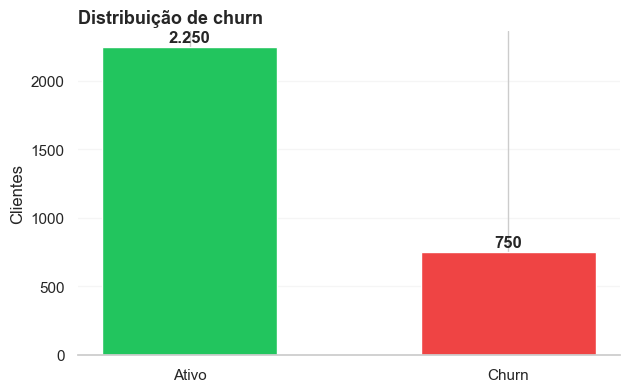

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\distribuicao_churn.png


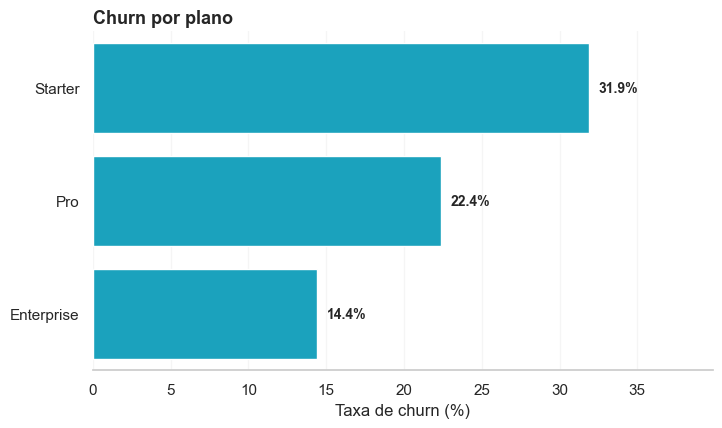

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\churn_por_plano.png


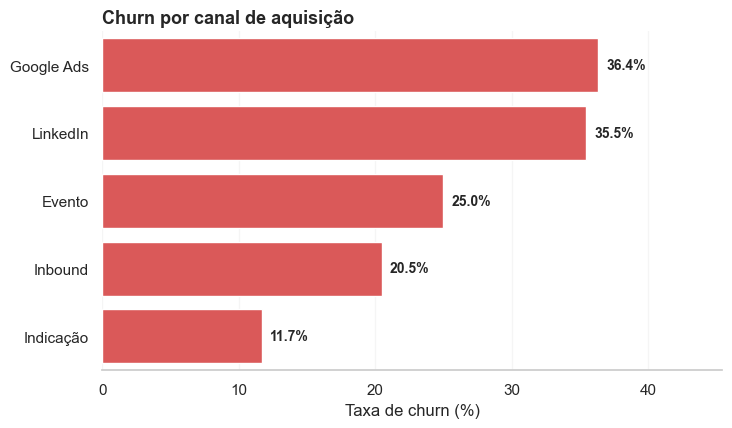

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\churn_por_canal.png


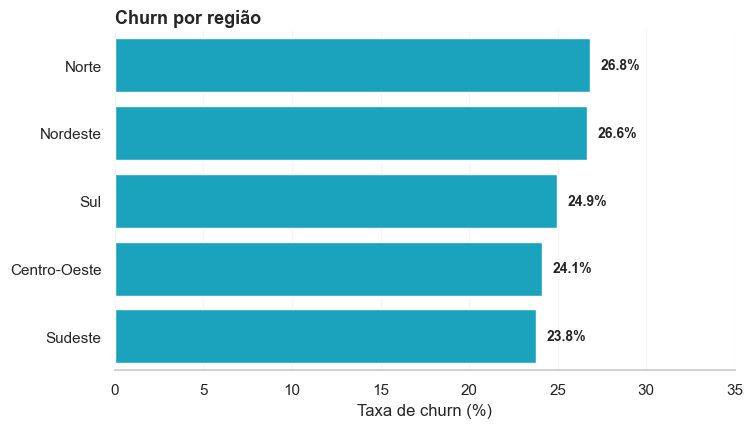

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\churn_por_regiao.png


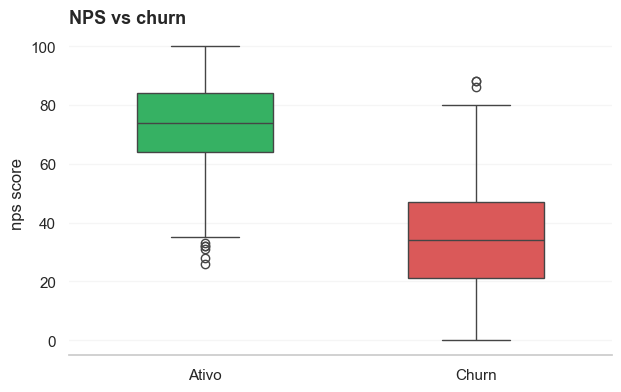

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\boxplot_nps_churn.png


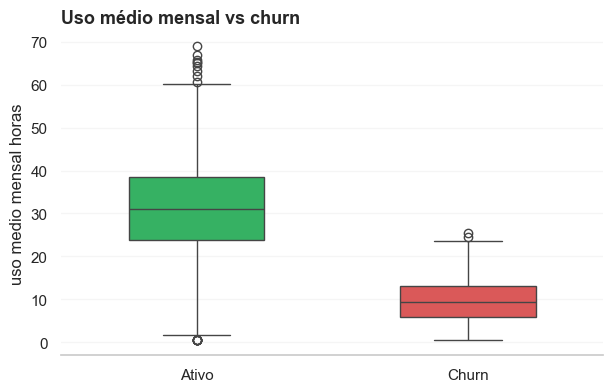

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\boxplot_uso_churn.png


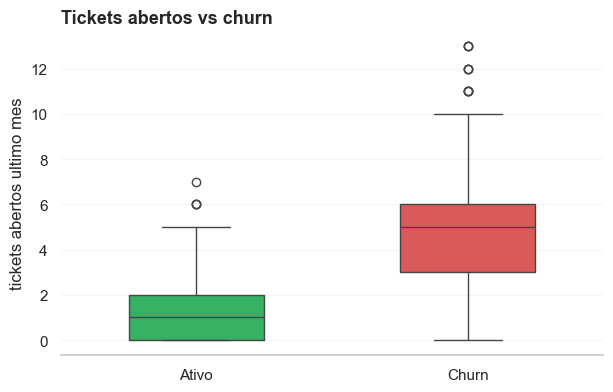

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\boxplot_tickets_churn.png


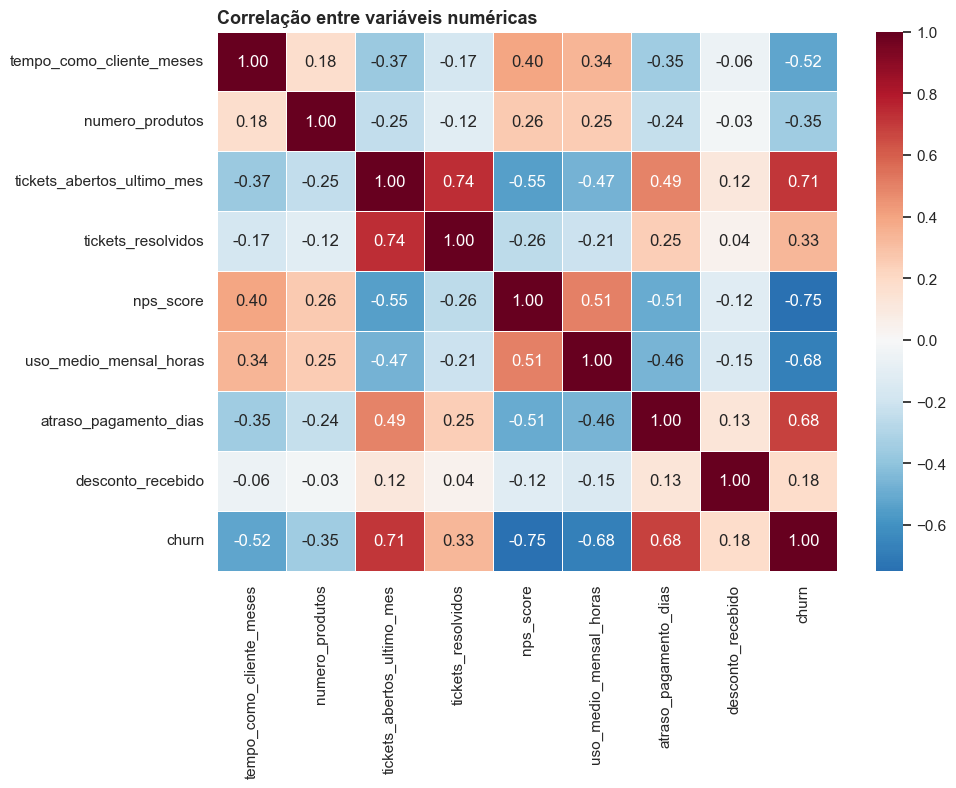

Salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\assets\correlacao_variaveis_numericas.png


In [3]:
plot_df = df.copy()
plot_df["status"] = plot_df["churn"].map({0: "Ativo", 1: "Churn"})

def save_figure(fig, filename):
    output = ASSETS_DIR / filename
    fig.savefig(output, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Salvo em: {output}")

counts = plot_df["status"].value_counts().reindex(["Ativo", "Churn"])
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(counts.index, counts.values, color=[COLOR_ACTIVE, COLOR_CHURN], width=0.55)
ax.set_title("Distribuição de churn", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Clientes")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.18)
ax.spines[["top", "right", "left"]].set_visible(False)
for bar in bars:
    value = int(bar.get_height())
    ax.text(bar.get_x() + bar.get_width() / 2, value + 35, f"{value:,}".replace(",", "."), ha="center", fontweight="bold")
save_figure(fig, "distribuicao_churn.png")

def churn_rate_by_category(category, title, filename, color=COLOR_CHURN):
    rates = df.groupby(category)["churn"].mean().mul(100).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4.4))
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color=color)
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.set_xlabel("Taxa de churn (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(35, rates.max() * 1.25))
    ax.grid(axis="x", alpha=0.18)
    ax.spines[["top", "right", "left"]].set_visible(False)
    for i, value in enumerate(rates.values):
        ax.text(value + 0.6, i, f"{value:.1f}%", va="center", fontsize=10, fontweight="bold")
    save_figure(fig, filename)

churn_rate_by_category("plano", "Churn por plano", "churn_por_plano.png", COLOR_PRIMARY)
churn_rate_by_category("canal_aquisicao", "Churn por canal de aquisição", "churn_por_canal.png", COLOR_CHURN)
churn_rate_by_category("regiao", "Churn por região", "churn_por_regiao.png", COLOR_PRIMARY)

boxplots = [
    ("nps_score", "NPS vs churn", "boxplot_nps_churn.png"),
    ("uso_medio_mensal_horas", "Uso médio mensal vs churn", "boxplot_uso_churn.png"),
    ("tickets_abertos_ultimo_mes", "Tickets abertos vs churn", "boxplot_tickets_churn.png"),
]
for column, title, filename in boxplots:
    fig, ax = plt.subplots(figsize=(7, 4.2))
    sns.boxplot(data=plot_df, x="status", y=column, palette={"Ativo": COLOR_ACTIVE, "Churn": COLOR_CHURN}, ax=ax, width=0.5)
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(column.replace("_", " "))
    ax.grid(axis="y", alpha=0.18)
    ax.spines[["top", "right", "left"]].set_visible(False)
    save_figure(fig, filename)

numeric_columns = [
    "tempo_como_cliente_meses",
    "numero_produtos",
    "tickets_abertos_ultimo_mes",
    "tickets_resolvidos",
    "nps_score",
    "uso_medio_mensal_horas",
    "atraso_pagamento_dias",
    "desconto_recebido",
    "churn",
]
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df[numeric_columns].corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Correlação entre variáveis numéricas", loc="left", fontsize=13, fontweight="bold")
save_figure(fig, "correlacao_variaveis_numericas.png")

## 3. Pré-processamento, split e SMOTE

In [4]:
FEATURE_COLUMNS = [
    "plano",
    "tempo_como_cliente_meses",
    "numero_produtos",
    "tickets_abertos_ultimo_mes",
    "tickets_resolvidos",
    "nps_score",
    "uso_medio_mensal_horas",
    "atraso_pagamento_dias",
    "desconto_recebido",
    "canal_aquisicao",
    "regiao",
]
NUMERIC_FEATURES = [
    "tempo_como_cliente_meses",
    "numero_produtos",
    "tickets_abertos_ultimo_mes",
    "tickets_resolvidos",
    "nps_score",
    "uso_medio_mensal_horas",
    "atraso_pagamento_dias",
    "desconto_recebido",
]
CATEGORICAL_FEATURES = ["plano", "canal_aquisicao", "regiao"]

X = df[FEATURE_COLUMNS].copy()
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", encoder, CATEGORICAL_FEATURES),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print("Treino original:", y_train.value_counts().to_dict())
print("Treino após SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())
print("Teste:", y_test.value_counts().to_dict())

Treino original: {0: 1800, 1: 600}
Treino após SMOTE: {0: 1800, 1: 1800}
Teste: {0: 450, 1: 150}


## 4. Treino e avaliação de modelos

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}

results = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    metrics = {
        "modelo": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    results.append(metrics)
    predictions[model_name] = {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "confusion_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
    }

    print(f"\n{model_name}")
    print("Matriz de confusão:")
    print(cm)

results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
display(results_df)


Logistic Regression
Matriz de confusão:
[[449   1]
 [  1 149]]



Random Forest
Matriz de confusão:
[[448   2]
 [  5 145]]



Gradient Boosting
Matriz de confusão:
[[447   3]
 [  3 147]]


,modelo,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.996667,0.993333,0.993333,0.993333,0.999970
1,Gradient Boosting,0.990000,0.980000,0.980000,0.980000,0.999659
2,Random Forest,0.988333,0.986395,0.966667,0.976431,0.999704


## 5. Salvamento do melhor modelo, preprocessor e artefatos

In [6]:
best_row = results_df.iloc[0]
best_model_name = best_row["modelo"]
best_model = models[best_model_name]
best_prediction = predictions[best_model_name]

try:
    feature_names = preprocessor.get_feature_names_out().tolist()
except AttributeError:
    categorical_names = list(preprocessor.named_transformers_["cat"].get_feature_names(CATEGORICAL_FEATURES))
    feature_names = NUMERIC_FEATURES + categorical_names

clean_feature_names = [
    name.replace("num__", "").replace("cat__", "").replace("canal_aquisicao_", "canal_").replace("regiao_", "regiao_").replace("plano_", "plano_")
    for name in feature_names
]

feature_importance = None
if hasattr(best_model, "feature_importances_"):
    feature_importance = best_model.feature_importances_.tolist()

artifacts = {
    "best_model_name": best_model_name,
    "metrics": best_row.to_dict(),
    "confusion_matrix": best_prediction["confusion_matrix"].tolist(),
    "roc_curve": {
        "fpr": best_prediction["fpr"].tolist(),
        "tpr": best_prediction["tpr"].tolist(),
        "thresholds": best_prediction["thresholds"].tolist(),
    },
    "feature_names": clean_feature_names,
    "feature_importance": feature_importance,
}

joblib.dump(best_model, MODELS_DIR / "churn_model.pkl")
joblib.dump(preprocessor, MODELS_DIR / "churn_preprocessor.pkl")
joblib.dump(artifacts, OUTPUTS_DIR / "model_artifacts.joblib")
results_df.to_csv(OUTPUTS_DIR / "comparativo_modelos.csv", index=False)

print(f"Melhor modelo: {best_model_name}")
print(f"Modelo salvo em: {MODELS_DIR / 'churn_model.pkl'}")
print(f"Preprocessor salvo em: {MODELS_DIR / 'churn_preprocessor.pkl'}")
print(f"Comparativo salvo em: {OUTPUTS_DIR / 'comparativo_modelos.csv'}")

Melhor modelo: Logistic Regression
Modelo salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\models\churn_model.pkl
Preprocessor salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\models\churn_preprocessor.pkl
Comparativo salvo em: C:\Users\userr\customer-churn-prediction-python-ai-1\outputs\comparativo_modelos.csv
